
# Taller: Deep Learning con MedMNIST, Perceptrón y CNN

## 1. Introducción

El Deep Learning (aprendizaje profundo) ha revolucionado el análisis de imágenes médicas, permitiendo automatizar tareas complejas como la detección de enfermedades, la segmentación de órganos y la predicción de resultados clínicos.
A diferencia del *Machine Learning clásico*, donde los modelos dependen de variables predefinidas o “features” diseñadas manualmente, el Deep Learning aprende representaciones jerárquicas directamente desde los datos, capturando patrones espaciales, texturales y morfológicos difíciles de expresar con reglas humanas.

En este taller, construiremos y entrenaremos dos redes neuronales fundamentales:

1. Perceptrón simple, el modelo más básico, que aplica una transformación lineal y una función de activación. Servirá como punto de partida para comprender los fundamentos del entrenamiento neuronal.
2. Red Convolucional (CNN), un modelo más avanzado que introduce capas convolucionales capaces de detectar bordes, formas y texturas, lo que la hace especialmente potente en imágenes biomédicas.

Usaremos la base de datos [MedMNIST](https://medmnist.com), un conjunto de datasets diseñados específicamente para docencia e investigación ligera en visión médica. Cada subdataset está preprocesado y balanceado, lo que permite centrarse en los conceptos del modelado y no en la recolección o limpieza de datos.

En particular, trabajaremos con:

* PneumoniaMNIST: imágenes de radiografía de tórax etiquetadas como *normal* o *neumonía*.
* OrganAMNIST: imágenes de tomografía computarizada (CT) abdominal con 11 clases correspondientes a distintos órganos.

Al finalizar, habrás recorrido todo el flujo de trabajo de un modelo de Deep Learning aplicado a salud, desde la carga de datos hasta la evaluación final, entendiendo cómo cada componente (datos, arquitectura, optimización y métricas) influye en el desempeño.



## 2. Objetivos


1. Cargar y explorar datasets biomédicos (PneumoniaMNIST y OrganAMNIST), entendiendo su estructura, formato y balance de clases.
2. Preparar el flujo de datos (`DataLoader` y `transforms`) para procesar imágenes en lotes (batches) y normalizarlas adecuadamente.
3. Implementar y entrenar un Perceptrón simple, observando sus limitaciones frente a datos visuales complejos.
4. Construir y entrenar una Red Convolucional (CNN) básica, interpretando su arquitectura y ventajas sobre el perceptrón.
5. Visualizar curvas de aprendizaje (*loss* y *accuracy*) para identificar comportamientos de sobreajuste y subajuste.
6. Evaluar el modelo mediante métricas relevantes en contexto médico: *accuracy*, *F1-score*, *sensibilidad* y *matriz de confusión*.
7. Extender el análisis a clasificación multiclase, entrenando modelos capaces de reconocer distintos órganos en OrganAMNIST.
8. (Opcional) Introducir conceptos de *data augmentation* y buenas prácticas para mejorar la generalización de modelos en salud.


## 3. Dataset

![](img/medmnist.png)



In [1]:
# Instalación de librerias
!pip install medmnist torch torchvision scikit-learn

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms

from medmnist import PneumoniaMNIST, OrganAMNIST

from sklearn.metrics import  ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 4. CNN compacta
Ya analizamos el desempeño de un perceptrón simple, que sirve como línea base pero tiene limitaciones para capturar patrones espaciales en imágenes.
Ahora construiremos una Red Neuronal Convolucional (CNN) básica, que introduce capas convolucionales capaces de detectar bordes, formas y texturas, lo que la hace especialmente potente en imágenes biomédicas.
Arquitectura sugerida (rápida y estable):
```
Conv(1,16,3,pad=1) + ReLU + MaxPool(2)
Conv(16,32,3,pad=1) + ReLU + MaxPool(2)
Flatten -> Linear(32*8*8, 64) + ReLU -> Linear(64, 1)
```

#### **Ejercicio**
1) Implementa la CNN 
2) Define la función de pérdida como `nn.BCEWithLogitsLoss()`.
3) Define el optimizador como `torch.optim.Adam` con tasa de aprendizaje `lr=0.001`.
4) Implementa el ciclo de entrenamiento para 15 épocas.
    * En cada época, itera sobre `train_loader` y realiza:
        * Forward pass.
        * Cálculo de la pérdida.
        * Backpropagation y optimización.
    * Al final de cada época, evalúa el modelo en `val_loader` y registra la pérdida y precisión.
5) Al finalizar el entrenamiento, evalúa el modelo en `test_loader` y calcula el loss y accuracy.
6) Grafica las curvas de pérdida y precisión para train y val a lo largo de las épocas.
7) Responde:
    * ¿Cómo se comporta la pérdida y precisión en train vs val? ¿Hay sobreajuste?
    * ¿Cómo se comporta al entrenar con 200 épocas?



[CNN][01/15] loss_tr=0.552 acc_tr=0.740 | loss_val=0.4626 acc_val=0.750
[CNN][02/15] loss_tr=0.313 acc_tr=0.873 | loss_val=0.1937 acc_val=0.943
[CNN][03/15] loss_tr=0.170 acc_tr=0.937 | loss_val=0.1553 acc_val=0.945
[CNN][04/15] loss_tr=0.144 acc_tr=0.942 | loss_val=0.1577 acc_val=0.947
[CNN][05/15] loss_tr=0.141 acc_tr=0.945 | loss_val=0.1207 acc_val=0.958
[CNN][06/15] loss_tr=0.141 acc_tr=0.946 | loss_val=0.1166 acc_val=0.962
[CNN][07/15] loss_tr=0.123 acc_tr=0.954 | loss_val=0.1153 acc_val=0.964
[CNN][08/15] loss_tr=0.113 acc_tr=0.958 | loss_val=0.1059 acc_val=0.962
[CNN][09/15] loss_tr=0.107 acc_tr=0.959 | loss_val=0.1076 acc_val=0.964
[CNN][10/15] loss_tr=0.126 acc_tr=0.954 | loss_val=0.1033 acc_val=0.964
[CNN][11/15] loss_tr=0.110 acc_tr=0.957 | loss_val=0.1055 acc_val=0.958
[CNN][12/15] loss_tr=0.112 acc_tr=0.954 | loss_val=0.1006 acc_val=0.962
[CNN][13/15] loss_tr=0.102 acc_tr=0.964 | loss_val=0.0969 acc_val=0.968
[CNN][14/15] loss_tr=0.100 acc_tr=0.963 | loss_val=0.0961 acc_va

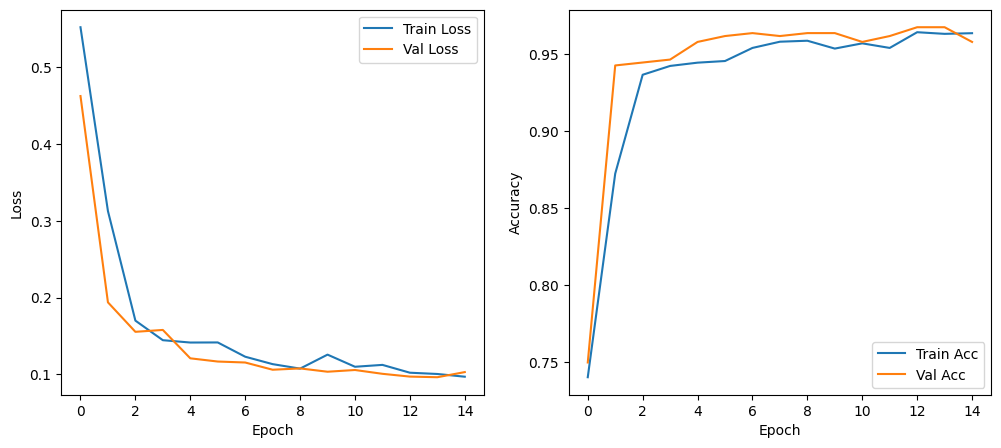

In [5]:
# <CODE>

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for x, y in loader:
        y = y.float()
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)    # Loss
        loss.backward()                # Backprop
        optimizer.step()               # Update
        # Métricas
        total_loss += loss.item() * x.size(0)
        p = torch.sigmoid(logits) >= 0.5 
        total_correct += (p == y).sum().item()
        total += x.size(0)
    return total_loss/total, total_correct/total

# Definir función de evaluación por época
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            y = y.float()
            x, y = x.to(device), y.to(device)
            logits = model(x)              # Forward
            loss = criterion(logits, y)    # Loss
            # Métricas
            total_loss += loss.item() * x.size(0)
            p = torch.sigmoid(logits) >= 0.5 

            total_correct += (p == y).sum().item()
            total += x.size(0)
    return total_loss/total, total_correct/total

class SmallCNN(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 28->14
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(4),  # 14->7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16*8*8, 64), nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = PneumoniaMNIST(split="train", download=True, size=64, transform=transform)
val_dataset   = PneumoniaMNIST(split="val",   download=True, size=64, transform=transform)
test_dataset  = PneumoniaMNIST(split="test",  download=True, size=64, transform=transform)
idx2label = {0: "normal", 1: "pneumonia"}



BATCH_SIZE = 128
num_workers = 2

pin = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=num_workers, pin_memory=pin, drop_last=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=pin, drop_last=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=pin, drop_last=False)

cnn = SmallCNN().to(device)
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

EPOCHS = 15
train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = train_one_epoch(cnn, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_one_epoch(cnn, val_loader, criterion, device)
    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc); val_accs.append(val_acc)
    print(f"[CNN][{epoch:02d}/{EPOCHS}] loss_tr={train_loss:.3f} acc_tr={train_acc:.3f} | loss_val={val_loss:.4f} acc_val={val_acc:.3f}")

# eval test
test_loss, test_acc = eval_one_epoch(cnn, test_loader, criterion, device)
print(f"[CNN] Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


#### **Ejercicio**
Las tarjetas gráficas (GPU) son esenciales para entrenar modelos de Deep Learning de manera eficiente, ya que permiten realizar cálculos en paralelo y acelerar significativamente el proceso de entrenamiento. Colab ofrece acceso gratuito a GPU, lo que facilita la experimentación con modelos más complejos y conjuntos de datos más grandes. Modifica el codigo anterior para entrenar solo utilizando CPU con 15 epocas. ¿Cómo afecta esto al tiempo de entrenamiento y al desempeño del modelo?

[CNN][01/15] loss_tr=0.577 acc_tr=0.732 | loss_val=0.5340 acc_val=0.742
[CNN][02/15] loss_tr=0.434 acc_tr=0.784 | loss_val=0.3188 acc_val=0.899
[CNN][03/15] loss_tr=0.227 acc_tr=0.922 | loss_val=0.1724 acc_val=0.933
[CNN][04/15] loss_tr=0.165 acc_tr=0.935 | loss_val=0.1434 acc_val=0.958
[CNN][05/15] loss_tr=0.141 acc_tr=0.945 | loss_val=0.1301 acc_val=0.956
[CNN][06/15] loss_tr=0.127 acc_tr=0.950 | loss_val=0.1271 acc_val=0.952
[CNN][07/15] loss_tr=0.128 acc_tr=0.951 | loss_val=0.1184 acc_val=0.956
[CNN][08/15] loss_tr=0.119 acc_tr=0.954 | loss_val=0.1060 acc_val=0.964
[CNN][09/15] loss_tr=0.111 acc_tr=0.961 | loss_val=0.0997 acc_val=0.966
[CNN][10/15] loss_tr=0.109 acc_tr=0.956 | loss_val=0.0987 acc_val=0.966
[CNN][11/15] loss_tr=0.105 acc_tr=0.959 | loss_val=0.0942 acc_val=0.969
[CNN][12/15] loss_tr=0.098 acc_tr=0.962 | loss_val=0.0975 acc_val=0.964
[CNN][13/15] loss_tr=0.098 acc_tr=0.961 | loss_val=0.0964 acc_val=0.966
[CNN][14/15] loss_tr=0.104 acc_tr=0.957 | loss_val=0.0909 acc_va

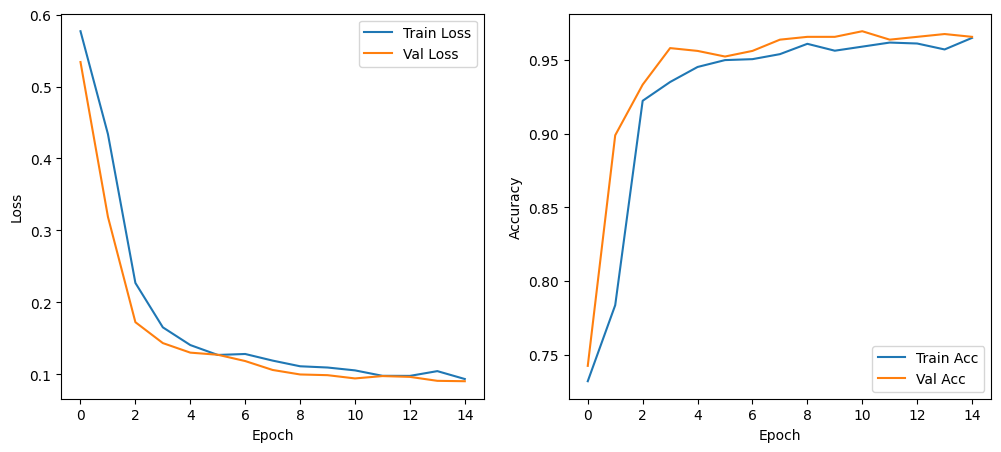

In [6]:
# <CODE>
class SmallCNN(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 28->14
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(4),  # 14->7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16*8*8, 64), nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

device = torch.device("cpu")  # Forzar uso de CPU
cnn = SmallCNN().to(device)
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

EPOCHS = 15
train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = train_one_epoch(cnn, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_one_epoch(cnn, val_loader, criterion, device)
    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc); val_accs.append(val_acc)
    print(f"[CNN][{epoch:02d}/{EPOCHS}] loss_tr={train_loss:.3f} acc_tr={train_acc:.3f} | loss_val={val_loss:.4f} acc_val={val_acc:.3f}")

# eval test
test_loss, test_acc = eval_one_epoch(cnn, test_loader, criterion, device)
print(f"[CNN] Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



## 5. Multiclase: OrganAMNIST (11 clases)

Usaremos OrganAMNIST (CT abdominal) con 11 clases. A diferencia del caso binario, ahora el modelo termina en 11 logits y la pérdida es `CrossEntropyLoss` (no se usa `sigmoid`, ni umbral).

Clases (índice → nombre):
0: bladder, 1: femur-left, 2: femur-right, 3: heart, 4: kidney-left, 5: kidney-right, 6: liver, 7: lung-left, 8: lung-right, 9: pancreas, 10: spleen

#### **Ejercicio**

1. Carga OrganAMNIST a 64×64 y prepara `train_loader` , `val_loader` y `test_loader`
2. Genera un plot con algunas imágenes y sus etiquetas.
3. Implementa la CNN + MLP con salida de 11 clases.
4. Entrena 15–20 épocas con `CrossEntropyLoss` y `Adam(lr=1e-3)`, registrando *loss* y *accuracy* en train/val (si usas val).
5. Evalúa en test: *loss*, *accuracy* y **matriz de confusión**.
6. Responde:
    * ¿Dónde se confunde más (qué órganos)?



In [ ]:
# <CODE>
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tf = transforms.Compose([transforms.ToTensor()])
train_dataset = OrganAMNIST(split="train", download=True, size=64, as_rgb=False, transform=tf)
test_dataset  = OrganAMNIST(split="test",  download=True, size=64, as_rgb=False, transform=tf)
val_dataset   = OrganAMNIST(split="val",   download=True, size=64, as_rgb=False, transform=tf)

BATCH_SIZE = 128
pin = torch.cuda.is_available()
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=pin, drop_last=True)
test_dataloader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin, drop_last=False)
val_dataloader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin, drop_last=False)

index_2_label = {
    0:'bladder', 1:'femur-left', 2:'femur-right', 3:'heart', 4:'kidney-left',
    5:'kidney-right', 6:'liver', 7:'lung-left', 8:'lung-right', 9:'pancreas', 10:'spleen'
}

class SmallCNN(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 28->14
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(4),  # 14->7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16*8*8, 64), nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# Definir función de entrenamiento por época
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for x, y in loader:
        y = y.squeeze().long()  
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)    # Loss
        loss.backward()                # Backprop
        optimizer.step()               # Update
        # Métricas
        total_loss += loss.item() * x.size(0)
        p = torch.argmax(logits, dim=1)
        total_correct += (p == y).sum().item()
        total += x.size(0)
    return total_loss/total, total_correct/total

# Definir función de evaluación por época
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            y = y.squeeze().long()
            x, y = x.to(device), y.to(device)
            logits = model(x)              # Forward
            loss = criterion(logits, y)    # Loss
            # Métricas
            total_loss += loss.item() * x.size(0)
            p = torch.argmax(logits, dim=1)
            total_correct += (p == y).sum().item()
            total += x.size(0)
    return total_loss/total, total_correct/total

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn = SmallCNN(num_classes=11).to(device)
criterion_mc = nn.CrossEntropyLoss()
optimizer_mc = torch.optim.Adam(cnn.parameters(), lr=1e-3)

EPOCHS = 15
train_losses, train_accs = [], []
val_losses, val_accs = [], []
for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = train_one_epoch(cnn, train_dataloader, optimizer_mc, criterion_mc, device)
    val_loss, val_acc = eval_one_epoch(cnn, val_dataloader, criterion_mc, device)
    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc); val_accs.append(val_acc)
    print(f"[CNN][{epoch:02d}/{EPOCHS}] loss_tr={train_loss:.3f} acc_tr={train_acc:.3f} | loss_val={val_loss:.4f} acc_val={val_acc:.3f}")

# eval test
test_loss, test_acc = eval_one_epoch(cnn, test_dataloader, criterion_mc, device)
print(f"[CNN] Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
# matrix de confusión
y_true, y_pred = [], []
cnn.eval()
with torch.no_grad():
    for x, y in test_dataloader:
        y = y.squeeze().long()
        x, y = x.to(device), y.to(device)
        logits = cnn(x)              # Forward
        p = torch.argmax(logits, dim=1)
        y_true.extend(y.cpu().numpy().tolist())
        y_pred.extend(p.cpu().numpy().tolist())
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[index_2_label[i] for i in range(11)])
disp.plot(xticks_rotation='vertical')


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

[CNN][01/15] loss_tr=1.042 acc_tr=0.646 | loss_val=0.3491 acc_val=0.918
[CNN][02/15] loss_tr=0.410 acc_tr=0.863 | loss_val=0.2095 acc_val=0.949
[CNN][03/15] loss_tr=0.286 acc_tr=0.904 | loss_val=0.1463 acc_val=0.965
[CNN][04/15] loss_tr=0.217 acc_tr=0.929 | loss_val=0.1522 acc_val=0.953
[CNN][05/15] loss_tr=0.174 acc_tr=0.944 | loss_val=0.1313 acc_val=0.966
[CNN][06/15] loss_tr=0.145 acc_tr=0.954 | loss_val=0.1382 acc_val=0.961
[CNN][07/15] loss_tr=0.119 acc_tr=0.962 | loss_val=0.1139 acc_val=0.968
[CNN][08/15] loss_tr=0.102 acc_tr=0.968 | loss_val=0.1109 acc_val=0.967
[CNN][09/15] loss_tr=0.088 acc_tr=0.974 | loss_val=0.1358 acc_val=0.964
[CNN][10/15] loss_tr=0.076 acc_tr=0.977 | loss_val=0.1398 acc_val=0.966
[CNN][11/15] loss_tr=0.065 acc_tr=0.981 | loss_val=0.1229 acc_val=0.969
[CNN][12/15] loss_tr=0.056 acc_tr=0.983 | loss_val=0.1442 acc_val=0.971
[CNN][13/15] loss_tr=0.046 acc_tr=0.987 | loss_val=0.1231 acc_val=0.969
